In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')



In [2]:
df=pd.read_csv("train.csv.xls")

In [3]:
df.head(5)  

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [6]:
df.department.unique()

array(['Sales & Marketing', 'Operations', 'Technology', 'Analytics',
       'R&D', 'Procurement', 'Finance', 'HR', 'Legal'], dtype=object)

In [7]:
df.region.unique()


array(['region_7', 'region_22', 'region_19', 'region_23', 'region_26',
       'region_2', 'region_20', 'region_34', 'region_1', 'region_4',
       'region_29', 'region_31', 'region_15', 'region_14', 'region_11',
       'region_5', 'region_28', 'region_17', 'region_13', 'region_16',
       'region_25', 'region_10', 'region_27', 'region_30', 'region_12',
       'region_21', 'region_8', 'region_32', 'region_6', 'region_33',
       'region_24', 'region_3', 'region_9', 'region_18'], dtype=object)

In [8]:
df.recruitment_channel.unique()

array(['sourcing', 'other', 'referred'], dtype=object)

In [9]:
df.shape

(54808, 14)

In [10]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [11]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score', 'is_promoted'],
      dtype='object')

EDA VISUALIZATION

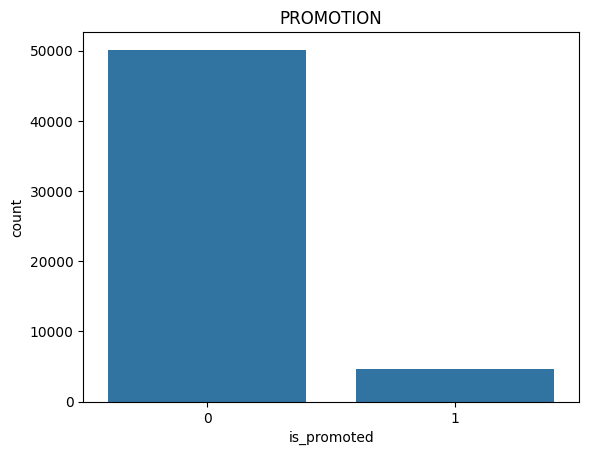

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_promoted',data=df)
plt.title("PROMOTION")
plt.show()

FEATURE ENGINEERING

In [13]:
df.drop(['employee_id'],axis=1,inplace=True)

In [14]:
df['education'].fillna(df['education'].mode()[0],inplace=True)
df['previous_year_rating'].fillna(df['previous_year_rating'].median(),inplace=True)

ENCODING

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['department', 'region', 'education', 'recruitment_channel']

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)],
    remainder='passthrough'
)

X = ct.fit_transform(df)

FEATURE SELECTION

In [ ]:
y = df['is_promoted']
X = df.drop('is_promoted', axis=1)
X = ct.fit_transform(X)

In [18]:
encoded_cols = ct.get_feature_names_out()
X = pd.DataFrame(X, columns=encoded_cols)


In [19]:
X.head()

,encoder__department_Finance,encoder__department_HR,encoder__department_Legal,encoder__department_Operations,encoder__department_Procurement,encoder__department_R&D,encoder__department_Sales & Marketing,encoder__department_Technology,encoder__region_region_10,encoder__region_region_11,...,encoder__recruitment_channel_referred,encoder__recruitment_channel_sourcing,remainder__gender,remainder__no_of_trainings,remainder__age,remainder__previous_year_rating,remainder__length_of_service,remainder__KPIs_met >80%,remainder__awards_won?,remainder__avg_training_score
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,35.0,5.0,8.0,1.0,0.0,49.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,30.0,5.0,4.0,0.0,0.0,60.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,34.0,3.0,7.0,0.0,0.0,50.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,2.0,39.0,1.0,10.0,0.0,0.0,50.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,45.0,3.0,2.0,0.0,0.0,73.0


In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

MODEL SELECTION

In [21]:
rf_cls=RandomForestClassifier(random_state=42)

RANDOOM FOREST(HYPER PARAMETER TUNING)

In [22]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100,400,],
    'max_depth': [3, 5],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=rf_cls,
    param_grid=param_dist,
    cv=3,
    n_jobs=-1,
    verbose=2
    )
grid_search.fit(X_train,y_train)



Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5], 'n_estimators': [100, 400]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [23]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 5, 'n_estimators': 100}

In [24]:
y_pred_rf = grid_search.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
accuracy_rf = accuracy_score(y_test, y_pred_rf)


Accuracy: 0.9209085933223864
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     10054
           1       1.00      0.05      0.09       908

    accuracy                           0.92     10962
   macro avg       0.96      0.52      0.52     10962
weighted avg       0.93      0.92      0.89     10962



GRADIENT BOOSTING


In [25]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score


# Initialize Gradient Boosting
gb_clf = GradientBoostingClassifier(random_state=42)
param_grid = {
    'n_estimators':[50,100],      # number of trees
    'learning_rate':[0.1, 0.2],    # step size shrinkage
    'max_depth':[3,5]         # depth of individual trees        
}
grid_search = GridSearchCV(
    estimator=gb_clf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,verbose=2)
# Train
grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.1, 0.2], 'max_depth': [3, 5], 'n_estimators': [50, 100]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [26]:
best_gb= grid_search.best_estimator_
grid_search.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

In [27]:
y_pred_gb = grid_search.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
accuracy_gb = accuracy_score(y_test, y_pred_gb)


Accuracy: 0.9423462871738734
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10054
           1       0.92      0.33      0.49       908

    accuracy                           0.94     10962
   macro avg       0.93      0.66      0.73     10962
weighted avg       0.94      0.94      0.93     10962



DESICION TREE

In [28]:
from sklearn.tree import DecisionTreeClassifier
DT_model=DecisionTreeClassifier(random_state=42)
DT_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
DT_model_predictions=DT_model.predict(X_test)
print(classification_report(y_test,DT_model_predictions ))
accuracy_dt = accuracy_score(y_test, DT_model_predictions)


              precision    recall  f1-score   support

           0       0.95      0.94      0.94     10054
           1       0.40      0.45      0.42       908

    accuracy                           0.90     10962
   macro avg       0.67      0.70      0.68     10962
weighted avg       0.90      0.90      0.90     10962



LOGISTIC REGRESSION

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [31]:
LOG_model=LogisticRegression(max_iter=1000,random_state=42)
LOG_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred_lg = LOG_model.predict(X_test)

In [33]:

class_report = classification_report(y_test, y_pred_lg)
print("Classification Report:")
print(class_report)
accuracy_lg = accuracy_score(y_test, y_pred_lg)

print("Logistic Regression Accuracy:", accuracy_lg)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96     10054
           1       0.78      0.26      0.39       908

    accuracy                           0.93     10962
   macro avg       0.86      0.63      0.68     10962
weighted avg       0.92      0.93      0.92     10962

Logistic Regression Accuracy: 0.9326765188834154


CONFUSION MATRIX

In [34]:

confusion_mat = confusion_matrix(y_test, y_pred_lg)
print("Confusion Matrix:")
print(confusion_mat)

Confusion Matrix:
[[9989   65]
 [ 673  235]]


CONFUSION MATRIX VISUALIZATION

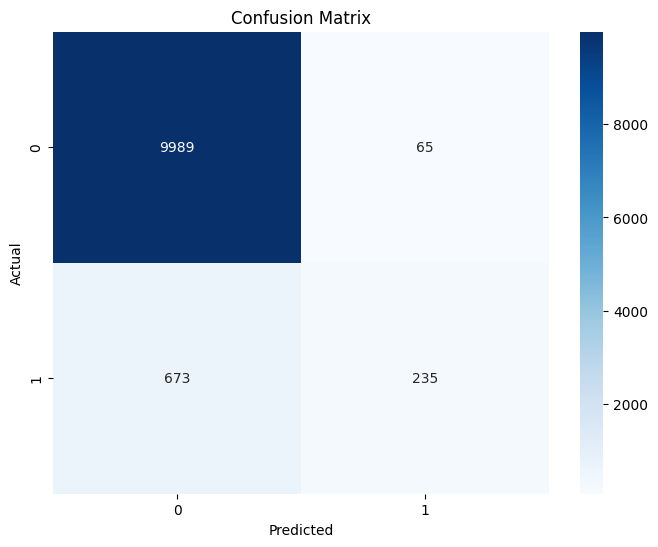

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, cmap='Blues', fmt='d', xticklabels=df["is_promoted"].unique(),
            yticklabels=df["is_promoted"].unique())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [49]:


y_score_lg = LOG_model.predict_proba(X_test)[:, 1]  # positive class
fpr, tpr, _ = roc_curve(y_test, y_score_lg)
roc_auc = auc(fpr, tpr)




In [50]:
y_test_bin = label_binarize(y_test, classes=[0,1])  # adjust classes list
n_classes = y_test_bin.shape[1]





In [51]:
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], LOG_model.predict_proba(X_test)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])



In [53]:
y_score = LOG_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)



ROC AOC CURVE VISUALIZATION

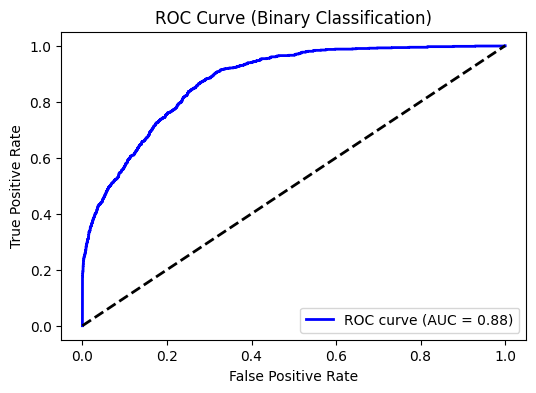

In [55]:

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Binary Classification)')
plt.legend(loc="lower right")
plt.show()

In [61]:
print(np.unique(y_train))
print(np.unique(y_test))

[0 1]
[0 1]


SVM MODEL

In [62]:
#SVM model

SVC_model=SVC()
SVC_model.fit(X_train,y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [63]:
#predict the model
y_pred_svm=SVC_model.predict(X_test)    

In [64]:

print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     10054
           1       0.91      0.13      0.23       908

    accuracy                           0.93     10962
   macro avg       0.92      0.56      0.59     10962
weighted avg       0.93      0.93      0.90     10962



In [65]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.9267469439883232


In [66]:

confusion_mat = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:")
print(confusion_mat)

Confusion Matrix:
[[10042    12]
 [  791   117]]


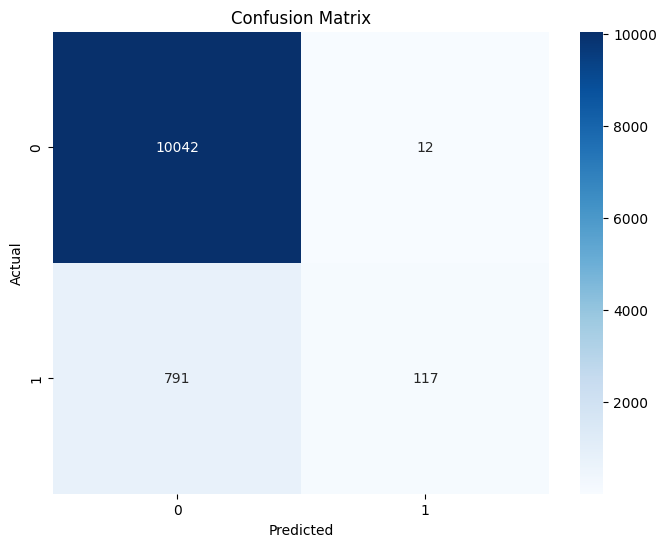

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, cmap='Blues', fmt='d', xticklabels=df["is_promoted"].unique(),
            yticklabels=df["is_promoted"].unique())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

KNN MODEL

In [ ]:
KNN_model=KNeighborsClassifier()
KNN_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:

y_pred_knn=KNN_model.predict(X_test)
print(classification_report(y_test,y_pred_knn))

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

              precision    recall  f1-score   support

           0       0.93      0.99      0.96     10054
           1       0.48      0.12      0.19       908

    accuracy                           0.92     10962
   macro avg       0.70      0.55      0.57     10962
weighted avg       0.89      0.92      0.89     10962

KNN Accuracy: 0.9161649334063127


In [ ]:
# AUC score
auc_knn = roc_auc_score(y_test, y_prob_knn)
print("KNN ROC-AUC:", auc_knn)

# ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure()
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {roc_auc_knn:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

NameError: name 'y_prob_knn' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_auc_score

# Logistic Regression
y_pred_lr = LOG_model.predict(X_test)
y_proba_lr = LOG_model.predict_proba(X_test)[:, 1]
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
logloss_lr = log_loss(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Random Forest
y_pred_rf = grid_search.predict(X_test)
y_proba_rf = grid_search.predict_proba(X_test)[:, 1]
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
logloss_rf = log_loss(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# Gradient Boosting
y_pred_gb = grid_search.predict(X_test)
y_proba_gb = grid_search.predict_proba(X_test)[:, 1]
accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
logloss_gb = log_loss(y_test, y_proba_gb)
auc_gb = roc_auc_score(y_test, y_proba_gb)

# Decision Tree
y_pred_dt = DT_model.predict(X_test)
y_proba_dt = DT_model.predict_proba(X_test)[:, 1]
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
logloss_dt = log_loss(y_test, y_proba_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

# K-Nearest Neighbors
y_pred_knn = KNN_model.predict(X_test)
y_proba_knn = KNN_model.predict_proba(X_test)[:, 1]
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
logloss_knn = log_loss(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)    

# SVM
y_pred_svm = SVC_model.predict(X_test)          
y_proba_svm = SVC_model.decision_function(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)
    

c:\Users\ziya1\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\ziya1\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\ziya1\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\ziya1\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\ziya1\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with featu

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting","Desicion Tree","SVM","KNN"],
    "Accuracy": [accuracy_lr, accuracy_rf, accuracy_gb,accuracy_dt,accuracy_svm,accuracy_knn],
    "AUC": [auc_lr, auc_rf, auc_gb,auc_dt,auc_svm,auc_knn]
})

results

,Model,Accuracy,AUC
0,Logistic Regression,0.932677,0.876706
1,Random Forest,0.916804,0.724224
2,Gradient Boosting,0.916804,0.724224
3,Desicion Tree,0.906404,0.506655
4,SVM,0.926747,0.815044
5,KNN,0.916165,0.709930
